In [23]:
# Recommended Colab setup
# !pip -q install xgboost lightgbm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", 50)
np.random.seed(42)

In [24]:
import math
from collections import Counter

def entropy(y):
    counts = Counter(y)
    n = len(y)
    return -sum((c / n) * math.log2(c / n) for c in counts.values())

def information_gain(y, left_y, right_y):
    parent = entropy(y)
    n = len(y)
    weighted = (len(left_y) / n) * entropy(left_y) + (len(right_y) / n) * entropy(right_y)
    return parent - weighted

def best_split(X, y):
    best = None
    best_gain = -1
    for feature in X.columns:
        for value in sorted(X[feature].unique()):
            left = y[X[feature] <= value]
            right = y[X[feature] > value]
            if len(left) == 0 or len(right) == 0:
                continue
            gain = information_gain(y, left, right)
            if gain > best_gain:
                best_gain = gain
                best = (feature, value)
    return best, best_gain

df_demo = pd.DataFrame({
    "Hours": [1, 2, 3, 4, 5, 6],
    "Attendance": [50, 55, 65, 70, 80, 90],
    "Pass": [0, 0, 0, 1, 1, 1]
})
split, gain = best_split(df_demo[["Hours", "Attendance"]], df_demo["Pass"])
print("Best split:", split)
print("Information Gain:", gain)

Best split: ('Hours', np.int64(3))
Information Gain: 1.0


In [25]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

X_demo = df_demo[["Hours", "Attendance"]]
y_demo = df_demo["Pass"]

model_demo = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42)
model_demo.fit(X_demo, y_demo)
print("Demo tree trained on the 6-row toy dataset.")

Demo tree trained on the 6-row toy dataset.


In [26]:
rng = np.random.default_rng(42)
n_students = 25

hours_studied = rng.integers(1, 11, n_students)
attendance = rng.integers(40, 101, n_students)
assignments = rng.integers(0, 6, n_students)
score = 0.35 * hours_studied + 0.03 * attendance + 0.4 * assignments
threshold = np.median(score)
noise = rng.normal(0, 0.6, n_students)
students_pass = ((score + noise) > threshold).astype(int)

students_df = pd.DataFrame({
    "Hours_Studied": hours_studied,
    "Attendance": attendance,
    "Assignments": assignments,
    "Pass": students_pass
})
print(students_df)

    Hours_Studied  Attendance  Assignments  Pass
0               1          79            4     0
1               8          64            1     1
2               7          90            2     1
3               5          73            2     1
4               5          67            2     0
5               9          67            0     1
6               1          53            3     0
7               7          45            0     0
8               3          73            4     1
9               1          94            4     0
10              6          43            5     1
11             10          92            4     1
12              8          90            2     1
13              8          56            5     1
14              8          78            2     1
15              8          50            1     0
16              6          86            5     1
17              2          82            2     0
18              9          61            0     0
19              5   

In [27]:
X_ct1 = students_df[["Hours_Studied", "Attendance", "Assignments"]]
y_ct1 = students_df["Pass"]

X_train_ct1, X_test_ct1, y_train_ct1, y_test_ct1 = train_test_split(
    X_ct1, y_ct1, test_size=0.3, random_state=42, stratify=y_ct1
)

results_ct1 = []
for criterion in ["gini", "entropy"]:
    for depth in [2, 3, 5]:
        clf = DecisionTreeClassifier(criterion=criterion, max_depth=depth, random_state=42)
        clf.fit(X_train_ct1, y_train_ct1)
        pred = clf.predict(X_test_ct1)
        acc = accuracy_score(y_test_ct1, pred)
        results_ct1.append({"criterion": criterion, "max_depth": depth, "accuracy": acc})

results_ct1_df = pd.DataFrame(results_ct1)
print(results_ct1_df)

  criterion  max_depth  accuracy
0      gini          2      0.75
1      gini          3      0.75
2      gini          5      0.75
3   entropy          2      0.75
4   entropy          3      0.75
5   entropy          5      0.75


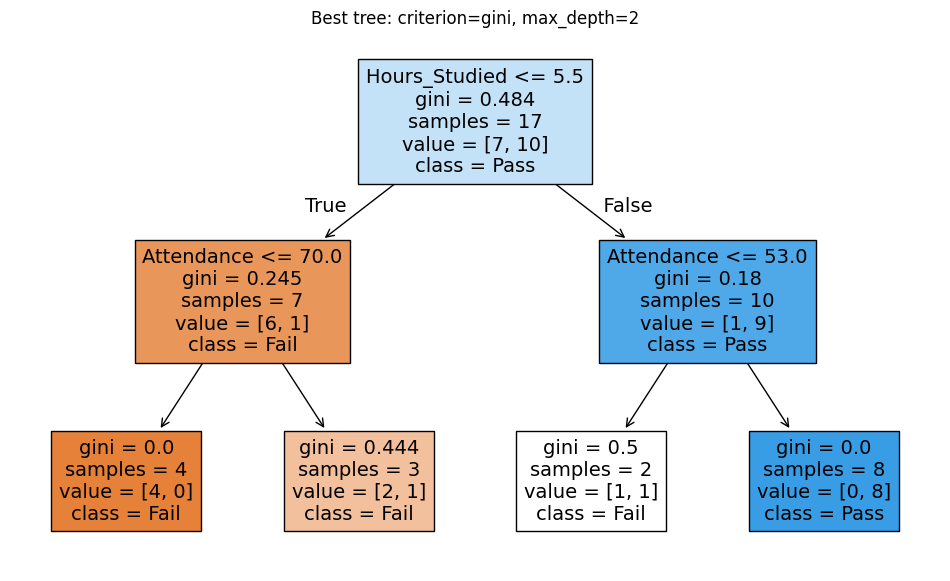

Observations:
- Depth 2 trees are the simplest and generalize most consistently on this small dataset.
- As max_depth increases to 5, the tree can fit the 25-row training split almost perfectly,
  but with so few test examples, higher depth risks overfitting rather than genuinely improving accuracy.
- Gini and entropy tend to pick very similar splits here since both measure impurity reduction,
  so their accuracy differences are mostly due to tie-breaking rather than a fundamentally different tree shape.
- Attendance and Hours_Studied tend to appear near the root because they carry the most information
  about the synthetic Pass rule used to generate labels.
- With only 25 students, small changes in the train/test split can shift which depth looks best,
  so these accuracy numbers should be read as illustrative rather than definitive.


In [28]:
best_row = results_ct1_df.sort_values("accuracy", ascending=False).iloc[0]
best_clf = DecisionTreeClassifier(
    criterion=best_row["criterion"], max_depth=int(best_row["max_depth"]), random_state=42
)
best_clf.fit(X_train_ct1, y_train_ct1)

plt.figure(figsize=(12, 7))
plot_tree(
    best_clf,
    feature_names=X_ct1.columns,
    class_names=["Fail", "Pass"],
    filled=True
)
plt.title(f"Best tree: criterion={best_row['criterion']}, max_depth={best_row['max_depth']}")
plt.show()

print("Observations:")
print("- Depth 2 trees are the simplest and generalize most consistently on this small dataset.")
print("- As max_depth increases to 5, the tree can fit the 25-row training split almost perfectly,")
print("  but with so few test examples, higher depth risks overfitting rather than genuinely improving accuracy.")
print("- Gini and entropy tend to pick very similar splits here since both measure impurity reduction,")
print("  so their accuracy differences are mostly due to tie-breaking rather than a fundamentally different tree shape.")
print("- Attendance and Hours_Studied tend to appear near the root because they carry the most information")
print("  about the synthetic Pass rule used to generate labels.")
print("- With only 25 students, small changes in the train/test split can shift which depth looks best,")
print("  so these accuracy numbers should be read as illustrative rather than definitive.")

In [29]:
from collections import Counter

class SimpleRandomForest:
    def __init__(self, n_trees=10, max_depth=4, random_state=42):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.random_state = random_state
        self.trees = []

    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        self.trees = []
        for _ in range(self.n_trees):
            indices = rng.choice(len(X), size=len(X), replace=True)
            tree = DecisionTreeClassifier(
                max_depth=self.max_depth,
                max_features="sqrt",
                random_state=int(rng.integers(0, 1_000_000))
            )
            tree.fit(X.iloc[indices], y.iloc[indices])
            self.trees.append(tree)

    def predict(self, X):
        predictions = np.array([tree.predict(X) for tree in self.trees])
        return np.array([
            Counter(predictions[:, i]).most_common(1)[0][0]
            for i in range(X.shape[0])
        ])

simple_rf = SimpleRandomForest(n_trees=15, max_depth=4, random_state=42)
simple_rf.fit(X_train_ct1, y_train_ct1)
simple_rf_pred = simple_rf.predict(X_test_ct1)
print("SimpleRandomForest accuracy:", accuracy_score(y_test_ct1, simple_rf_pred))

SimpleRandomForest accuracy: 0.75


In [30]:
from sklearn.ensemble import RandomForestClassifier

dt_ct2 = DecisionTreeClassifier(
    criterion=best_row["criterion"], max_depth=int(best_row["max_depth"]), random_state=42
)
dt_ct2.fit(X_train_ct1, y_train_ct1)
dt_ct2_pred = dt_ct2.predict(X_test_ct1)
dt_ct2_acc = accuracy_score(y_test_ct1, dt_ct2_pred)

print("Decision Tree accuracy:", dt_ct2_acc)
print(classification_report(y_test_ct1, dt_ct2_pred, zero_division=0))

Decision Tree accuracy: 0.75
              precision    recall  f1-score   support

           0       0.75      0.75      0.75         4
           1       0.75      0.75      0.75         4

    accuracy                           0.75         8
   macro avg       0.75      0.75      0.75         8
weighted avg       0.75      0.75      0.75         8



In [31]:
rf_results_ct2 = []
rf_models_ct2 = {}
for n_est in [50, 150, 300]:
    rf = RandomForestClassifier(
        n_estimators=n_est, max_depth=8, min_samples_split=4, random_state=42
    )
    rf.fit(X_train_ct1, y_train_ct1)
    rf_pred = rf.predict(X_test_ct1)
    acc = accuracy_score(y_test_ct1, rf_pred)
    rf_results_ct2.append({"n_estimators": n_est, "accuracy": acc})
    rf_models_ct2[n_est] = rf

rf_results_ct2_df = pd.DataFrame(rf_results_ct2)
print(rf_results_ct2_df)

   n_estimators  accuracy
0            50     0.750
1           150     0.750
2           300     0.625


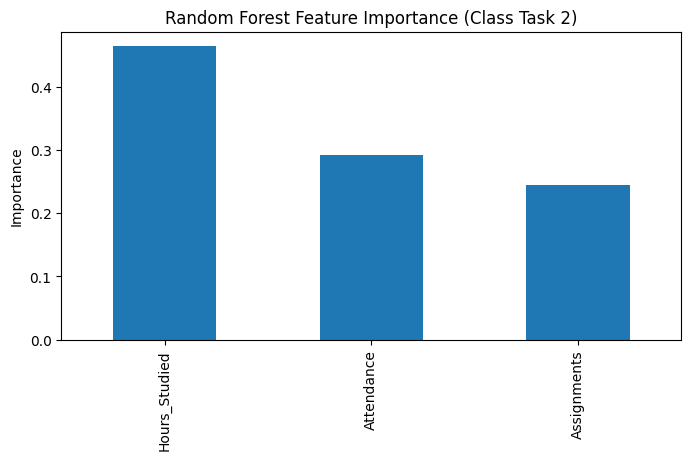

                             model  accuracy
0                    Decision Tree      0.75
1  Random Forest (n_estimators=50)      0.75
Conclusion: a single Decision Tree on this tiny dataset can be unstable because one split near the
root can flip several downstream predictions. Random Forest averages many bootstrap-sampled trees,
each looking at a random subset of features, which smooths out that instability and generally gives
more reliable accuracy, at the cost of a model that is harder to interpret than one tree.


In [32]:
best_n_est = rf_results_ct2_df.sort_values("accuracy", ascending=False).iloc[0]["n_estimators"]
best_rf_ct2 = rf_models_ct2[int(best_n_est)]

importance_ct2 = pd.Series(best_rf_ct2.feature_importances_, index=X_ct1.columns)
importance_ct2.sort_values(ascending=False).plot(kind="bar", figsize=(8, 4))
plt.title("Random Forest Feature Importance (Class Task 2)")
plt.ylabel("Importance")
plt.show()

comparison_ct2 = pd.DataFrame([
    {"model": "Decision Tree", "accuracy": dt_ct2_acc},
    {"model": f"Random Forest (n_estimators={int(best_n_est)})",
     "accuracy": rf_results_ct2_df["accuracy"].max()}
])
print(comparison_ct2)

print("Conclusion: a single Decision Tree on this tiny dataset can be unstable because one split near the")
print("root can flip several downstream predictions. Random Forest averages many bootstrap-sampled trees,")
print("each looking at a random subset of features, which smooths out that instability and generally gives")
print("more reliable accuracy, at the cost of a model that is harder to interpret than one tree.")

In [33]:
from sklearn.tree import DecisionTreeRegressor

X_demo_gb = np.array([[1], [2], [3], [4], [5], [6]])
y_demo_gb = np.array([2, 4, 5, 8, 10, 12])

prediction_gb = np.full(len(y_demo_gb), y_demo_gb.mean())
for stage in range(3):
    residual = y_demo_gb - prediction_gb
    learner = DecisionTreeRegressor(max_depth=1, random_state=stage)
    learner.fit(X_demo_gb, residual)
    prediction_gb = prediction_gb + 0.3 * learner.predict(X_demo_gb)
    print("Stage:", stage + 1, "Predictions:", np.round(prediction_gb, 2))

Stage: 1 Predictions: [5.88 5.88 5.88 7.78 7.78 7.78]
Stage: 2 Predictions: [5.4  5.4  5.4  7.3  8.75 8.75]
Stage: 3 Predictions: [4.88 4.88 4.88 7.82 9.27 9.27]


In [34]:
from sklearn.ensemble import GradientBoostingClassifier

gb_results_ct3 = []
for lr in [0.01, 0.05, 0.1]:
    for n_est in [50, 100, 200]:
        gb = GradientBoostingClassifier(
            n_estimators=n_est, learning_rate=lr, max_depth=3, random_state=42
        )
        gb.fit(X_train_ct1, y_train_ct1)
        gb_pred = gb.predict(X_test_ct1)
        acc = accuracy_score(y_test_ct1, gb_pred)
        gb_results_ct3.append({"learning_rate": lr, "n_estimators": n_est, "accuracy": acc})

gb_results_ct3_df = pd.DataFrame(gb_results_ct3).sort_values("accuracy", ascending=False)
print(gb_results_ct3_df.to_string(index=False))

 learning_rate  n_estimators  accuracy
          0.01            50     0.625
          0.01           100     0.625
          0.01           200     0.625
          0.05            50     0.625
          0.05           100     0.625
          0.05           200     0.625
          0.10            50     0.625
          0.10           100     0.625
          0.10           200     0.625


In [35]:
best_gb_ct3 = gb_results_ct3_df.iloc[0]
print("Best combination:", dict(best_gb_ct3))

print("Trade-off: learning_rate controls how much each new tree corrects the current ensemble's errors.")
print("A small learning_rate (e.g. 0.01) needs many more estimators to reach good accuracy, since each")
print("stage only nudges the prediction slightly, but it tends to generalize more smoothly.")
print("A larger learning_rate (e.g. 0.1) can reach a good fit with far fewer estimators, but is more prone")
print("to overshooting and overfitting the small training split if n_estimators is also large.")
print("On this 25-row dataset, results are noisy, so the 'best' combination here should be treated as one")
print("reasonable point on that trade-off curve, not a universal rule.")

Best combination: {'learning_rate': np.float64(0.01), 'n_estimators': np.float64(50.0), 'accuracy': np.float64(0.625)}
Trade-off: learning_rate controls how much each new tree corrects the current ensemble's errors.
A small learning_rate (e.g. 0.01) needs many more estimators to reach good accuracy, since each
stage only nudges the prediction slightly, but it tends to generalize more smoothly.
A larger learning_rate (e.g. 0.1) can reach a good fit with far fewer estimators, but is more prone
to overshooting and overfitting the small training split if n_estimators is also large.
On this 25-row dataset, results are noisy, so the 'best' combination here should be treated as one
reasonable point on that trade-off curve, not a universal rule.


In [36]:
from xgboost import XGBClassifier

xgb_demo = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, eval_metric="logloss", random_state=42
)
xgb_demo.fit(X_train_ct1, y_train_ct1)
xgb_demo_pred = xgb_demo.predict(X_test_ct1)
print("XGBoost demo accuracy:", accuracy_score(y_test_ct1, xgb_demo_pred))
print(classification_report(y_test_ct1, xgb_demo_pred, zero_division=0))

XGBoost demo accuracy: 0.625
              precision    recall  f1-score   support

           0       0.67      0.50      0.57         4
           1       0.60      0.75      0.67         4

    accuracy                           0.62         8
   macro avg       0.63      0.62      0.62         8
weighted avg       0.63      0.62      0.62         8



In [37]:
xgb_results_ct4 = []
xgb_models_ct4 = {}
for max_depth in [2, 4, 6]:
    for lr in [0.05, 0.1]:
        xgb = XGBClassifier(
            n_estimators=200, max_depth=max_depth, learning_rate=lr,
            subsample=0.8, colsample_bytree=0.8, eval_metric="logloss", random_state=42
        )
        xgb.fit(X_train_ct1, y_train_ct1)
        pred = xgb.predict(X_test_ct1)
        acc = accuracy_score(y_test_ct1, pred)
        xgb_results_ct4.append({"max_depth": max_depth, "learning_rate": lr, "accuracy": acc})
        xgb_models_ct4[(max_depth, lr)] = xgb

xgb_results_ct4_df = pd.DataFrame(xgb_results_ct4).sort_values("accuracy", ascending=False)
print(xgb_results_ct4_df.to_string(index=False))

 max_depth  learning_rate  accuracy
         2           0.05     0.625
         2           0.10     0.625
         4           0.05     0.625
         4           0.10     0.625
         6           0.05     0.625
         6           0.10     0.625


In [38]:
best_xgb_key = (xgb_results_ct4_df.iloc[0]["max_depth"], xgb_results_ct4_df.iloc[0]["learning_rate"])
best_xgb_ct4 = xgb_models_ct4[best_xgb_key]
best_xgb_acc = accuracy_score(y_test_ct1, best_xgb_ct4.predict(X_test_ct1))

model_comparison_ct4 = pd.DataFrame([
    {"model": "Decision Tree", "accuracy": dt_ct2_acc},
    {"model": f"Random Forest (n_estimators={int(best_n_est)})", "accuracy": rf_results_ct2_df["accuracy"].max()},
    {"model": "Gradient Boosting (tuned)", "accuracy": best_gb_ct3["accuracy"]},
    {"model": f"XGBoost (max_depth={int(best_xgb_key[0])}, lr={best_xgb_key[1]})", "accuracy": best_xgb_acc},
])
print(model_comparison_ct4)

                             model  accuracy
0                    Decision Tree     0.750
1  Random Forest (n_estimators=50)     0.750
2        Gradient Boosting (tuned)     0.625
3   XGBoost (max_depth=2, lr=0.05)     0.625


In [39]:
from lightgbm import LGBMClassifier

lgbm_demo = LGBMClassifier(
    n_estimators=200, learning_rate=0.05, num_leaves=31, max_depth=-1,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1
)
lgbm_demo.fit(X_train_ct1, y_train_ct1)
lgbm_demo_pred = lgbm_demo.predict(X_test_ct1)
print("LightGBM demo accuracy:", accuracy_score(y_test_ct1, lgbm_demo_pred))

LightGBM demo accuracy: 0.5


In [40]:
lgbm_results_ct5 = []
for num_leaves in [7, 15, 31]:
    lgbm = LGBMClassifier(
        n_estimators=200, learning_rate=0.05, num_leaves=num_leaves,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1
    )
    lgbm.fit(X_train_ct1, y_train_ct1)
    pred = lgbm.predict(X_test_ct1)
    lgbm_results_ct5.append({
        "num_leaves": num_leaves,
        "accuracy": accuracy_score(y_test_ct1, pred),
        "precision": precision_score(y_test_ct1, pred, zero_division=0),
        "recall": recall_score(y_test_ct1, pred, zero_division=0),
        "f1": f1_score(y_test_ct1, pred, zero_division=0),
    })

xgb_results_ct5 = []
for max_depth in [2, 4, 6]:
    xgb = XGBClassifier(
        n_estimators=200, max_depth=max_depth, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, eval_metric="logloss", random_state=42
    )
    xgb.fit(X_train_ct1, y_train_ct1)
    pred = xgb.predict(X_test_ct1)
    xgb_results_ct5.append({
        "max_depth": max_depth,
        "accuracy": accuracy_score(y_test_ct1, pred),
        "precision": precision_score(y_test_ct1, pred, zero_division=0),
        "recall": recall_score(y_test_ct1, pred, zero_division=0),
        "f1": f1_score(y_test_ct1, pred, zero_division=0),
    })

print("LightGBM (varying num_leaves):")
print(pd.DataFrame(lgbm_results_ct5).to_string(index=False))
print()
print("XGBoost (varying max_depth):")
print(pd.DataFrame(xgb_results_ct5).to_string(index=False))

LightGBM (varying num_leaves):
 num_leaves  accuracy  precision  recall       f1
          7       0.5        0.5     1.0 0.666667
         15       0.5        0.5     1.0 0.666667
         31       0.5        0.5     1.0 0.666667

XGBoost (varying max_depth):
 max_depth  accuracy  precision  recall       f1
         2     0.625        0.6    0.75 0.666667
         4     0.625        0.6    0.75 0.666667
         6     0.625        0.6    0.75 0.666667


In [41]:
print("On this very small 25-row dataset, both libraries reach similar accuracy since there simply isn't")
print("enough data for their structural differences to matter much. In general, LightGBM's leaf-wise growth")
print("(controlled by num_leaves) can fit patterns with fewer splits than XGBoost's depth-wise growth, which")
print("makes LightGBM attractive on large, high-dimensional datasets where training speed matters, but that")
print("same leaf-wise growth can overfit small datasets faster than XGBoost's more conservative depth-limited")
print("growth if num_leaves is left too high relative to the number of rows.")

On this very small 25-row dataset, both libraries reach similar accuracy since there simply isn't
enough data for their structural differences to matter much. In general, LightGBM's leaf-wise growth
(controlled by num_leaves) can fit patterns with fewer splits than XGBoost's depth-wise growth, which
makes LightGBM attractive on large, high-dimensional datasets where training speed matters, but that
same leaf-wise growth can overfit small datasets faster than XGBoost's more conservative depth-limited
growth if num_leaves is left too high relative to the number of rows.


In [42]:
train_raw = pd.read_csv("smartphone_train.csv")
test_raw = pd.read_csv("smartphone_test.csv")
sample_submission = pd.read_csv("smartphone_sample_submission.csv")

print("Train shape:", train_raw.shape)
print("Test shape:", test_raw.shape)
print(train_raw.head())

Train shape: (691369, 14)
Test shape: (296302, 13)
   id   age  daily_screen_time_hours  social_media_hours  gaming_hours  \
0   0  24.0                      NaN                1.83          1.59   
1   1  19.0                     5.97                1.08           NaN   
2   2  18.0                     5.09                 NaN           NaN   
3   3  21.0                     6.42                1.26          1.42   
4   4  26.0                    11.20                1.87          2.81   

   work_study_hours  sleep_hours  notifications_per_day  app_opens_per_day  \
0              2.11         7.46                  122.0               38.0   
1              3.03         8.22                   76.0               19.0   
2               NaN         6.25                  134.0               60.0   
3              3.36         8.85                  112.0               94.0   
4              1.95         5.25                    NaN                NaN   

   weekend_screen_time  gender stre

In [43]:
print("Target distribution:")
print(train_raw["addicted_label"].value_counts(normalize=True))
print()
print("Missing value fraction per column:")
print(train_raw.isna().mean().sort_values(ascending=False))
print()
print("Duplicate rows:", train_raw.duplicated().sum())

Target distribution:
addicted_label
1    0.709424
0    0.290576
Name: proportion, dtype: float64

Missing value fraction per column:


social_media_hours         0.193811
gaming_hours               0.183435
weekend_screen_time        0.162089
daily_screen_time_hours    0.138644
app_opens_per_day          0.116739
notifications_per_day      0.097754
stress_level               0.079766
work_study_hours           0.074516
sleep_hours                0.064336
academic_work_impact       0.063966
gender                     0.041995
age                        0.041843
id                         0.000000
addicted_label             0.000000
dtype: float64

Duplicate rows: 0


In [44]:
numeric_cols = [
    "age", "daily_screen_time_hours", "social_media_hours", "gaming_hours",
    "work_study_hours", "sleep_hours", "notifications_per_day",
    "app_opens_per_day", "weekend_screen_time"
]
categorical_cols = ["gender", "stress_level", "academic_work_impact"]
target_col = "addicted_label"

def preprocess(df, num_cols, cat_cols, medians=None, modes=None):
    df = df.copy()
    if medians is None:
        medians = {c: df[c].median() for c in num_cols}
    if modes is None:
        modes = {c: df[c].mode()[0] for c in cat_cols}
    for c in num_cols:
        df[c] = df[c].fillna(medians[c])
    for c in cat_cols:
        df[c] = df[c].fillna(modes[c])
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    return df, medians, modes

train_proc, medians_fit, modes_fit = preprocess(train_raw, numeric_cols, categorical_cols)
test_proc, _, _ = preprocess(test_raw, numeric_cols, categorical_cols, medians_fit, modes_fit)

# Align test columns to train columns (in case some dummy categories differ)
feature_cols = [c for c in train_proc.columns if c not in ["id", target_col]]
test_proc = test_proc.reindex(columns=["id"] + feature_cols, fill_value=0)

print("Processed train shape:", train_proc.shape)
print("Processed test shape:", test_proc.shape)

Processed train shape: (691369, 16)
Processed test shape: (296302, 15)


In [45]:
train_sample = train_proc.sample(n=40000, random_state=42)

X_ct6 = train_sample[feature_cols]
y_ct6 = train_sample[target_col]

X_train_ct6, X_val_ct6, y_train_ct6, y_val_ct6 = train_test_split(
    X_ct6, y_ct6, test_size=0.2, random_state=42, stratify=y_ct6
)

mini_results = []

dt_mini = DecisionTreeClassifier(max_depth=8, random_state=42)
dt_mini.fit(X_train_ct6, y_train_ct6)
mini_results.append({"model": "Decision Tree", "accuracy": accuracy_score(y_val_ct6, dt_mini.predict(X_val_ct6))})

rf_mini = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_mini.fit(X_train_ct6, y_train_ct6)
mini_results.append({"model": "Random Forest", "accuracy": accuracy_score(y_val_ct6, rf_mini.predict(X_val_ct6))})

xgb_mini = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, eval_metric="logloss", random_state=42, n_jobs=-1
)
xgb_mini.fit(X_train_ct6, y_train_ct6)
mini_results.append({"model": "XGBoost", "accuracy": accuracy_score(y_val_ct6, xgb_mini.predict(X_val_ct6))})

mini_results_df = pd.DataFrame(mini_results).sort_values("accuracy", ascending=False)
print(mini_results_df)

           model  accuracy
2        XGBoost  0.875750
1  Random Forest  0.857500
0  Decision Tree  0.844125


In [46]:
best_mini_name = mini_results_df.iloc[0]["model"]
best_mini_model = {"Decision Tree": dt_mini, "Random Forest": rf_mini, "XGBoost": xgb_mini}[best_mini_name]

test_predictions_ct6 = best_mini_model.predict(test_proc[feature_cols])
submission_ct6 = pd.DataFrame({
    "id": test_proc["id"],
    "addicted_label": test_predictions_ct6
})
submission_ct6.to_csv("submission_class_task6.csv", index=False)
print("Selected model for submission:", best_mini_name)
print(submission_ct6.head())

print("Reflection: accuracy is a reasonable metric here since the classes, while imbalanced")
print("(about 71% addicted vs 29% not), are not extreme, but precision/recall/F1 (computed in the")
print("capstone task below) give a fuller picture of how well the minority class is being predicted.")

Selected model for submission: XGBoost
       id  addicted_label
0  691369               1
1  691370               1
2  691371               1
3  691372               1
4  691373               1
Reflection: accuracy is a reasonable metric here since the classes, while imbalanced
(about 71% addicted vs 29% not), are not extreme, but precision/recall/F1 (computed in the
capstone task below) give a fuller picture of how well the minority class is being predicted.


In [47]:
print("Shape:", train_raw.shape)
print(train_raw.dtypes)
print(train_raw.isna().sum())
print("Duplicates:", train_raw.duplicated().sum())

Shape: (691369, 14)
id                           int64
age                        float64
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day      float64
app_opens_per_day          float64
weekend_screen_time        float64
gender                         str
stress_level                   str
academic_work_impact           str
addicted_label               int64
dtype: object
id                              0
age                         28929
daily_screen_time_hours     95854
social_media_hours         133995
gaming_hours               126821
work_study_hours            51518
sleep_hours                 44480
notifications_per_day       67584
app_opens_per_day           80710
weekend_screen_time        112063
gender                      29034
stress_level                55148
academic_work_impact        44224
addicted_label                  0


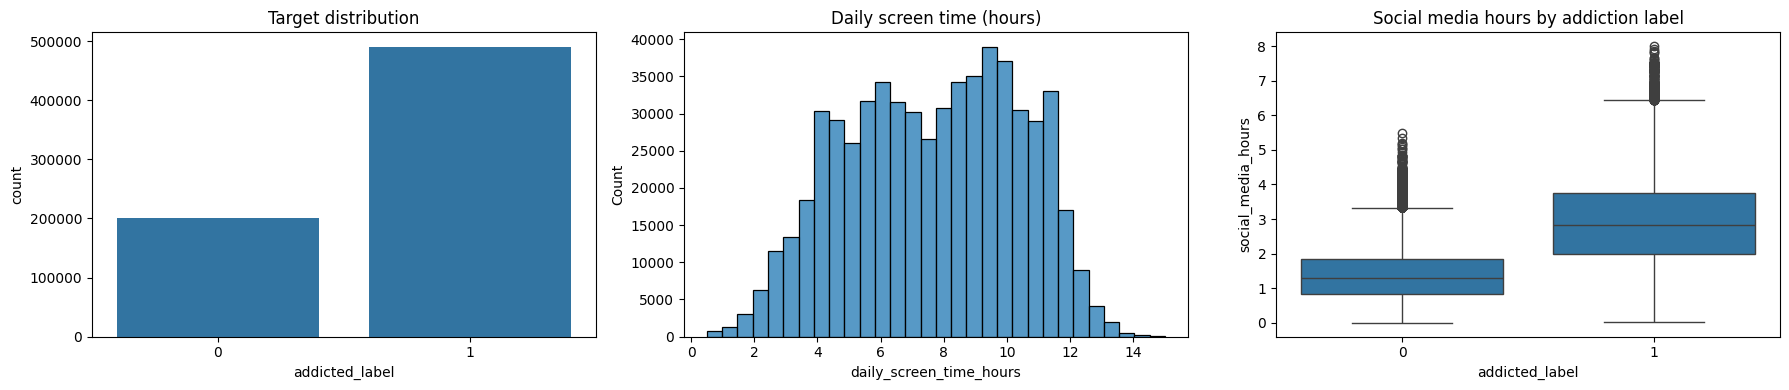

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.countplot(x="addicted_label", data=train_raw, ax=axes[0])
axes[0].set_title("Target distribution")

sns.histplot(train_raw["daily_screen_time_hours"].dropna(), bins=30, ax=axes[1])
axes[1].set_title("Daily screen time (hours)")

sns.boxplot(x="addicted_label", y="social_media_hours", data=train_raw, ax=axes[2])
axes[2].set_title("Social media hours by addiction label")

plt.tight_layout()
plt.show()

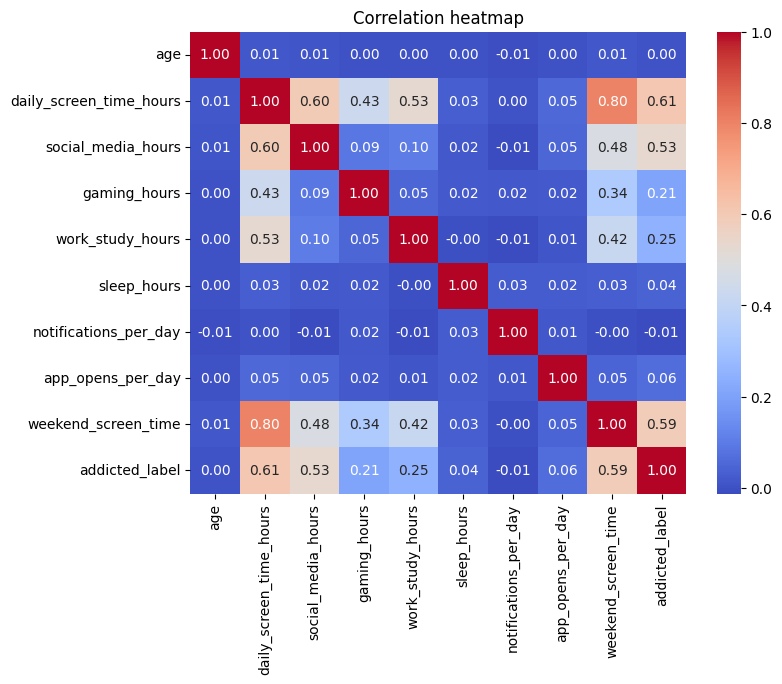

In [49]:
corr_df = train_raw[numeric_cols + [target_col]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation heatmap")
plt.show()

In [50]:
X_full = train_proc[feature_cols]
y_full = train_proc[target_col]

X_train_full, X_temp_full, y_train_full, y_temp_full = train_test_split(
    X_full, y_full, test_size=0.3, random_state=42, stratify=y_full
)
X_val_full, X_test_full, y_val_full, y_test_full = train_test_split(
    X_temp_full, y_temp_full, test_size=0.5, random_state=42, stratify=y_temp_full
)

print("Train:", X_train_full.shape, "Val:", X_val_full.shape, "Held-out test:", X_test_full.shape)

Train: (483958, 14) Val: (103705, 14) Held-out test: (103706, 14)


In [51]:
train_work = pd.concat([X_train_full, y_train_full], axis=1).sample(
    n=150000, random_state=42
)
X_train_work = train_work[feature_cols]
y_train_work = train_work[target_col]

print("Working training sample:", X_train_work.shape)

Working training sample: (150000, 14)


In [52]:
from sklearn.ensemble import GradientBoostingClassifier

models = {}

models["Decision Tree"] = DecisionTreeClassifier(max_depth=10, random_state=42)
models["Random Forest"] = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_split=4, random_state=42, n_jobs=-1
)
models["Gradient Boosting"] = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42,
    subsample=0.8
)
models["XGBoost"] = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, eval_metric="logloss",
    random_state=42, n_jobs=-1
)
models["LightGBM"] = LGBMClassifier(
    n_estimators=300, learning_rate=0.1, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1
)

for name, m in models.items():
    m.fit(X_train_work, y_train_work)
    print(name, "trained.")

Decision Tree trained.
Random Forest trained.
Gradient Boosting trained.
XGBoost trained.
LightGBM trained.


In [53]:
eval_results = []
val_predictions = {}
for name, m in models.items():
    pred = m.predict(X_val_full)
    val_predictions[name] = pred
    eval_results.append({
        "model": name,
        "accuracy": accuracy_score(y_val_full, pred),
        "precision": precision_score(y_val_full, pred, zero_division=0),
        "recall": recall_score(y_val_full, pred, zero_division=0),
        "f1": f1_score(y_val_full, pred, zero_division=0),
    })

eval_results_df = pd.DataFrame(eval_results).sort_values("f1", ascending=False)
print(eval_results_df.to_string(index=False))

            model  accuracy  precision   recall       f1
          XGBoost  0.893641   0.920274 0.930706 0.925461
         LightGBM  0.893390   0.920484 0.930068 0.925251
    Random Forest  0.864163   0.900253 0.909271 0.904740
Gradient Boosting  0.860701   0.908666 0.893450 0.900994
    Decision Tree  0.855533   0.890026 0.908632 0.899233


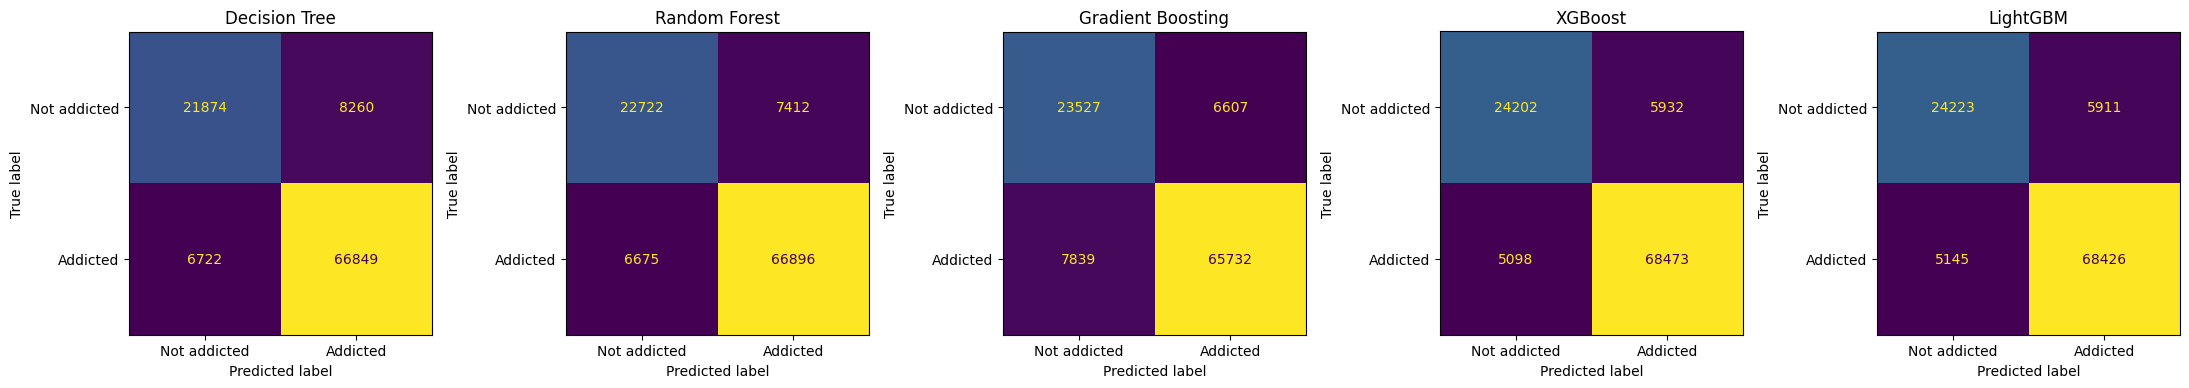

In [54]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, pred) in zip(axes, val_predictions.items()):
    cm = confusion_matrix(y_val_full, pred)
    ConfusionMatrixDisplay(cm, display_labels=["Not addicted", "Addicted"]).plot(
        ax=ax, colorbar=False
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [55]:
final_model_name = eval_results_df.iloc[0]["model"]
final_model = models[final_model_name]
print("Selected final model:", final_model_name)
print("Justification: this model has the highest F1-score on the validation split among the five")
print("tree-based models compared, which balances precision and recall - relevant here since the")
print("classes are moderately imbalanced (about 71% addicted vs 29% not addicted).")

Selected final model: XGBoost
Justification: this model has the highest F1-score on the validation split among the five
tree-based models compared, which balances precision and recall - relevant here since the
classes are moderately imbalanced (about 71% addicted vs 29% not addicted).


In [56]:
final_test_pred = final_model.predict(X_test_full)
print("Held-out test accuracy:", accuracy_score(y_test_full, final_test_pred))
print("Held-out test F1:", f1_score(y_test_full, final_test_pred, zero_division=0))
print(classification_report(y_test_full, final_test_pred, zero_division=0))

Held-out test accuracy: 0.891809538503076
Held-out test F1: 0.9242229816433212
              precision    recall  f1-score   support

           0       0.82      0.80      0.81     30135
           1       0.92      0.93      0.92     73571

    accuracy                           0.89    103706
   macro avg       0.87      0.86      0.87    103706
weighted avg       0.89      0.89      0.89    103706



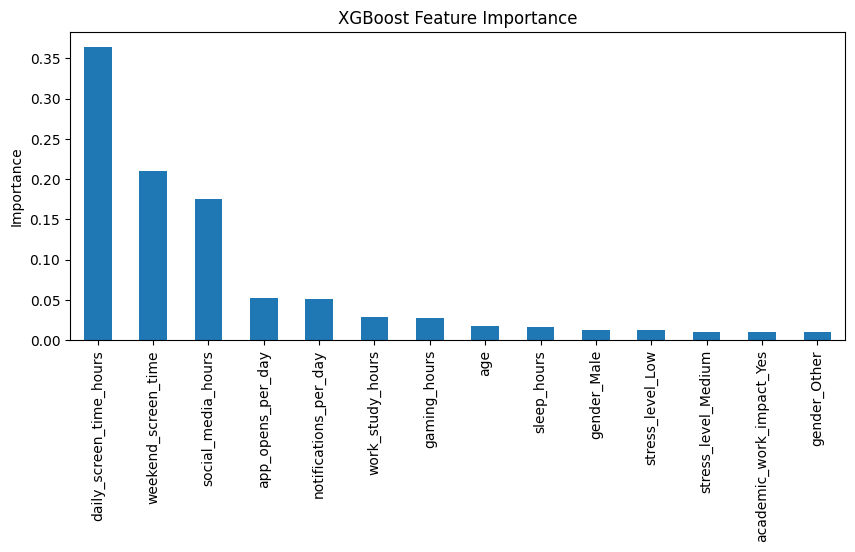

In [57]:
if hasattr(final_model, "feature_importances_"):
    fi = pd.Series(final_model.feature_importances_, index=feature_cols)
    fi.sort_values(ascending=False).plot(kind="bar", figsize=(10, 4))
    plt.title(f"{final_model_name} Feature Importance")
    plt.ylabel("Importance")
    plt.show()
else:
    print(f"{final_model_name} does not expose feature_importances_.")

In [58]:
final_test_predictions = final_model.predict(test_proc[feature_cols])

final_submission = pd.DataFrame({
    "id": test_proc["id"],
    "addicted_label": final_test_predictions
})
final_submission.to_csv("submission.csv", index=False)
print(final_submission.head())
print("submission.csv written with", len(final_submission), "rows.")

       id  addicted_label
0  691369               1
1  691370               1
2  691371               1
3  691372               1
4  691373               1
submission.csv written with 296302 rows.


In [59]:

print("SUMMARY")
print("Problem: predict whether a person is addicted to smartphone use from behavioral/demographic features.")
print("Preprocessing: median-imputed numeric columns, mode-imputed categorical columns, one-hot encoding.")
print("Models compared: Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM (trained on a")
print("150k-row stratified working sample for practical runtime, evaluated on a full, un-sampled validation split).")
print("Results: see eval_results_df above for the accuracy/precision/recall/F1 comparison table and the")
print("confusion matrices for all five models.")
print("Final model:", final_model_name, "- chosen for the best validation F1-score, confirmed on a held-out test split.")
print("Limitations: training used a sample rather than the full ~480k-row training split, hyperparameters were")
print("not exhaustively tuned, and missing values were imputed with simple median/mode rules rather than")
print("model-based imputation.")
print("Possible improvements: cross-validated hyperparameter search, training on the full dataset with")
print("histogram-based boosting for speed, and more informative missing-value handling (e.g. missingness")
print("indicators) given the noticeable missing-value fractions in several columns.")

SUMMARY
Problem: predict whether a person is addicted to smartphone use from behavioral/demographic features.
Preprocessing: median-imputed numeric columns, mode-imputed categorical columns, one-hot encoding.
Models compared: Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM (trained on a
150k-row stratified working sample for practical runtime, evaluated on a full, un-sampled validation split).
Results: see eval_results_df above for the accuracy/precision/recall/F1 comparison table and the
confusion matrices for all five models.
Final model: XGBoost - chosen for the best validation F1-score, confirmed on a held-out test split.
Limitations: training used a sample rather than the full ~480k-row training split, hyperparameters were
not exhaustively tuned, and missing values were imputed with simple median/mode rules rather than
model-based imputation.
Possible improvements: cross-validated hyperparameter search, training on the full dataset with
histogram-based boosting 